# SDS Assignment | A Barcelona Case

***Author:*** Juan Fonseca

## Part I: Socio-economic structure of Barcelona

This analysis explores two key elements of Barcelona's socio-economic structure: the spatial distribution of the population by nationality and the disposable income per capita. Three datasets from Barcelona's Open Data Service are used: 2022 Population by nationality (Spain/EU/Rest of foreign) and sex[<sup>1</sup>](#_blank "Available at: https://opendata-ajuntament.barcelona.cat/data/dataset/pad_mdbas_nacionalitat-g_sexe/resource/0d28f16c-c3de-46ba-99d4-1388e0247bfe"), 2022 Disposable income of households per capita (€) in the city of Barcelona[<sup>2</sup>](#_blank "Available at: https://opendata-ajuntament.barcelona.cat/data/dataset/78db0c75-fa56-4604-9510-8b92834a7fd2"), and the boundaries for administrative units of the city of Barcelona[<sup>3</sup>](#_blank "Available at: https://opendata-ajuntament.barcelona.cat/data/dataset/808daafa-d9ce-48c0-925a-fa5afdb1ed41").

In [1]:
# Importing the required packages
import pandas as pd
import geopandas as gpd
from libpysal import graph
import numpy as np
import seaborn as sns
import esda
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import contextily
import pointpats
from scipy import stats
from sklearn import preprocessing
from sklearn import cluster

In [2]:
## Loading the datasets
# URLs for the datasets
url_pop_nationality = "https://opendata-ajuntament.barcelona.cat/data/dataset/ae5116f1-b265-4602-9031-edd9a45f342b/resource/486e10e9-c22c-4418-8467-271fe51b2add/download"
url_income = "https://opendata-ajuntament.barcelona.cat/data/dataset/78db0c75-fa56-4604-9510-8b92834a7fd2/resource/3df0c5b9-de69-4c94-b924-57540e52932f/download/2022_renda_disponible_llars_per_persona.csv"
url_adm_units_bcn = "https://opendata-ajuntament.barcelona.cat/data/dataset/808daafa-d9ce-48c0-925a-fa5afdb1ed41/resource/11851135-6919-4dcb-91ed-821e5e87a428/download"

# Read datasets from URLs
pop_nationality_raw = pd.read_csv(url_pop_nationality)
income_bcn_raw = pd.read_csv(url_income)
# reading the seccio censal administrative units from the administrative units dataset
adm_units_bcn_raw = gpd.read_file(
    url_adm_units_bcn, layer="0301040100_SecCens_UNITATS_ADM"
)

In [3]:
# Creating a copy of the raw datasets to work with
pop_nationality = pop_nationality_raw.copy()
income_bcn = income_bcn_raw.copy()
adm_units_bcn = adm_units_bcn_raw.copy()

## A quick look at the data
# pop_nationality.head(100)
# income_bcn.head(100)
# adm_units_bcn.head(100)

## Pre-processing Population by nationality
### Creating a field for the join with the spatial data
# Standardise census section codes to 5 digits with leading zeros for consistent joining
pop_nationality["code_sec"] = (
    pop_nationality["Seccio_Censal"].astype("str").str.rjust(5, "0")
)

# A quick look at the data
# pop_nationality.head(100)

### Converting the number of people to a number
# Replacing ".." for 0 values and convert to float
pop_nationality["Valor"] = (
    pop_nationality["Valor"].str.replace("..", "0", regex=False).astype("float")
)

# Group by census section and nationality to sum populations
agg_nationality = (
    pop_nationality.groupby(["code_sec", "NACIONALITAT_G"])
    .agg({"Valor": "sum"})
    .reset_index()
)

### Calculating percentages of nationalities by census section
# Calculate the proportion of each nationality as a percentage within each census section
agg_nationality["proportion"] = 100 * (
    agg_nationality["Valor"]
    / agg_nationality.groupby("code_sec")["Valor"].transform("sum")
)


# Creating a dictionary to map the nationality codes to their respective names (based on definitions from
# Dimensions dels conjunts de dades del Padró Municipal d'habitants de la ciutat de Barcelona available at:
# https://opendata-ajuntament.barcelona.cat/data/ca/dataset/pad-dimensions/resource/b00be3f8-9328-4175-8689-24a25bc0907c)

nationality_mapping = {
    1: "Spanish",
    2: "European (excluding Spain)",
    3: "Rest of the world",
    4: "Unspecified",
}

# Apply mapping to create a readable Nationality column
agg_nationality["Nationality"] = agg_nationality["NACIONALITAT_G"].map(
    nationality_mapping
)

# Create total population dataset for merging with income data later
agg_total_pop = pop_nationality.groupby("code_sec").agg({"Valor": "sum"}).reset_index()
agg_total_pop = agg_total_pop.rename(columns={"Valor": "total_population"})

# Generate descriptive statistics for each nationality
desc_nat = agg_nationality.groupby("Nationality")["proportion"].describe()

# Pivot the dataframe so that each nationality becomes a column (one row per census section)
agg_nationality = agg_nationality.pivot_table(
    index="code_sec",
    columns="Nationality",
    values="proportion",
).reset_index()

# Standardise each nationality variable using robust scaling
for col in [
    "Spanish",
    "European (excluding Spain)",
    "Rest of the world",
    "Unspecified",
]:
    agg_nationality[col + "_std"] = preprocessing.robust_scale(agg_nationality[[col]])

## Pre-processing Income data
### Creating a field for the join with the spatial data from the district code and seccio censal
# Combine district code (2 digits) and census section (3 digits) with leading zeros for consistent joining
income_bcn["code_sec"] = income_bcn["Codi_Districte"].astype("str").str.rjust(
    2, "0"
) + income_bcn["Seccio_Censal"].astype("str").str.rjust(3, "0")

# Merge population data to income data for calculating weighted averages
income_bcn = income_bcn.merge(agg_total_pop, on="code_sec", how="left")

# Calculate the weighted average income per capita for the entire city
avg_income_per_capita = (
    sum(income_bcn["Import_Euros"] * income_bcn["total_population"])
    / income_bcn["total_population"].sum()
)

# Standardise income values using robust scaling
income_bcn["Income_std"] = preprocessing.robust_scale(income_bcn[["Import_Euros"]])

## Pre-processing the administrative units data
# Create census section code by concatenating district and section codes
adm_units_bcn["code_sec"] = adm_units_bcn["DISTRICTE"] + adm_units_bcn["SEC_CENS"]

# Start building the main spatial dataset with geometry
join_bcn = adm_units_bcn[["code_sec", "geometry"]].copy()

# Merge income data to spatial dataset
join_bcn = join_bcn.merge(
    income_bcn[
        [
            "code_sec",
            "Nom_Barri",
            "Nom_Districte",
            "Import_Euros",
            "Income_std",
        ]
    ],
    on="code_sec",
    how="left",
)

# Merge nationality proportions and set census section as index for easier spatial operations
join_bcn = join_bcn.merge(agg_nationality, on="code_sec", how="left").set_index(
    "code_sec"
)

# For visualisation, extract centroids of neighbourhoods for annotation on maps
# Extract old city centre (Ciutat Vella) centroid
ciutat_vella_bounds = (
    join_bcn[join_bcn["Nom_Districte"] == "Ciutat Vella"]
    .dissolve("Nom_Districte")
    .boundary
)
ciutat_vella_centroid = ciutat_vella_bounds.centroid.iloc[0]

# Extract Sarrià-St. Gervasi centroid
sarria_bounds = (
    join_bcn[join_bcn["Nom_Districte"] == "Sarrià-St. Gervasi"]
    .dissolve("Nom_Districte")
    .boundary
)
sarria_centroid = sarria_bounds.centroid.iloc[0]

# Extracting Nou Barris centroid for reference
nou_barris_bounds = (
    join_bcn[join_bcn["Nom_Districte"] == "Nou Barris"]
    .dissolve("Nom_Districte")
    .boundary
)
nou_barris_centroid = nou_barris_bounds.centroid.iloc[0]

Among the three main nationality categories, Spanish nationals form the majority across the city, followed by nationals from non-European countries, and then European nationals, representing 78%, 16%, and 6% of the total population, respectively. A very small portion of the population did not report their nationality (less than 0.5%); this category was excluded from further analysis.

When looking at spatial distributions, Spanish nationals predominate in most areas, except around the Old City District (Ciutat Vella), in locations such as the Gothic quarter and *el Raval*, where higher proportions of non-Spanish nationals are evident. These areas are known for their cultural diversity and significant tourist activity[<sup>4</sup>](#_blank "Ajuntament Barcelona, nd. Ciutat Vella. Available at: https://ajuntament.barcelona.cat/ciutatvella/es/el-distrito-y-sus-barrios"). European nationals show a consistent distribution across the city, with higher concentrations in the central and western areas. While nationals from non-European countries also show relatively high proportions around the city centre, some specific areas in the north and north-east stand out, where non-European nationals form the most predominant population group.

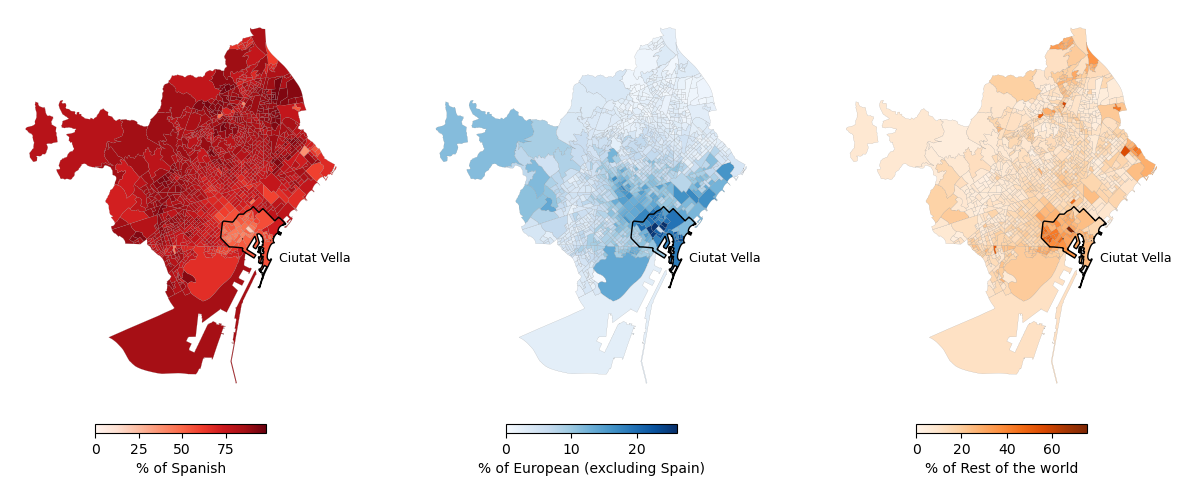

In [4]:
# Create a mapping from nationality to colour map for visualisation
cmap_dict = {
    "Spanish": "Reds",
    "European (excluding Spain)": "Blues",
    "Rest of the world": "Oranges",
}

# Plot a grid of maps to show the spatial distribution of each nationality group
fig, axes = plt.subplots(1, 3, figsize=(15, 15))
nationalities = ["Spanish", "European (excluding Spain)", "Rest of the world"]
for ax, nationality in zip(axes.flatten(), nationalities):
    # Plot the proportion of each nationality in each census section
    join_bcn.plot(
        column=nationality,
        cmap=cmap_dict[nationality],  # Use a different colour map for each nationality
        norm=colors.Normalize(vmin=0),
        edgecolor="gray",  # Borderline colour
        linewidth=0.1,  # Borderline width
        ax=ax,
        legend=True,
        legend_kwds={
            "orientation": "horizontal",
            "shrink": 0.5,
            "pad": 0.02,
            "label": f"% of {nationality}",
        },
    )
    ax.set_axis_off()  # Hide axis for cleaner map presentation

    # adding the boundary of the old city centre (Ciutat Vella) for reference and annotation with name
    ciutat_vella_bounds.plot(ax=ax, edgecolor="black", linewidth=1)
    ax.text(
        ciutat_vella_centroid.x + 1000,
        ciutat_vella_centroid.y - 800,
        s="Ciutat Vella",
        fontsize=9,
    )

The mean disposable income per capita in 2022 was estimated at €23,000. As shown in the map below, there are clear spatial differences in income levels across Barcelona. Areas with disposable incomes up to 1.8 times the average are concentrated in the western parts of the city, such as *Sarria*, *Sant Gervasi*, and *Les Tres Torres*, in the Sarria Sant Gervasi District. In contrast, lower income levels are more prevalent in the southern and northern districts, where disposable income is around half the city average.

Text(431035.404182356, 4591240.874606407, 'Nou Barris')

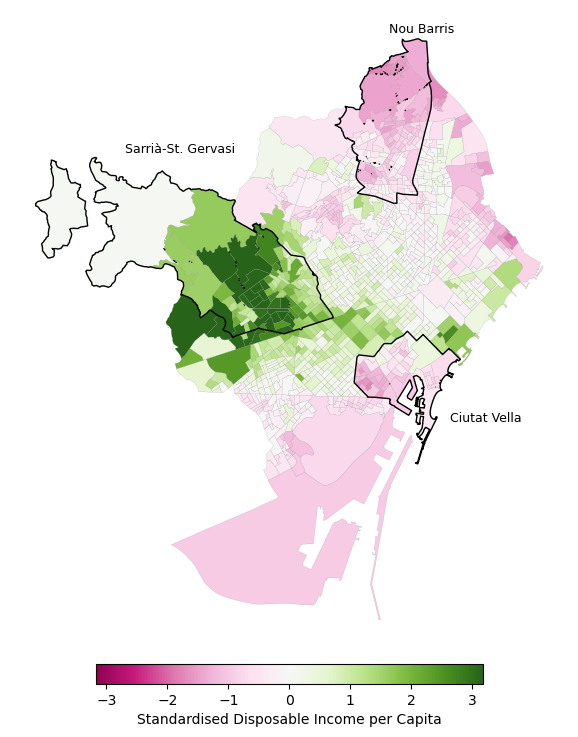

In [5]:
# Visualising the spatial distribution of disposable income ratio
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
join_bcn.plot(
    column="Income_std",
    ax=ax,
    cmap="PiYG",
    edgecolor="gray",  # Borderline color
    linewidth=0.1,  # Borderline width,
    legend=True,
    norm=colors.CenteredNorm(vcenter=0),
    legend_kwds={
        "orientation": "horizontal",
        "shrink": 0.5,
        "pad": 0.02,
        "label": "Standardised Disposable Income per Capita",
    },
)
ax.set_axis_off()

# adding the boundary of the old city centre (Ciutat Vella) for reference and annotation with name
ciutat_vella_bounds.plot(ax=ax, edgecolor="black", linewidth=1)
ax.text(
    ciutat_vella_centroid.x + 1000,
    ciutat_vella_centroid.y - 800,
    s="Ciutat Vella",
    fontsize=9,
)

# adding the boundary of Sarrià-St. Gervasi for reference and annotation with name
sarria_bounds.plot(ax=ax, edgecolor="black", linewidth=1)
ax.text(
    sarria_centroid.x - 1000,
    sarria_centroid.y + 2500,
    s="Sarrià-St. Gervasi",
    fontsize=9,
)

# adding the boundary of Nou Barris
nou_barris_bounds.plot(ax=ax, edgecolor="black", linewidth=1)
ax.text(nou_barris_centroid.x, nou_barris_centroid.y + 2500, s="Nou Barris", fontsize=9)

### Spatial autocorrelation in income and population by nationality 

The maps presented above may suggest that the spatial distributions of income and nationalities in Barcelona are not a result of a random process; that is, people with similar incomes tend to be close to each other, and people from other nationalities might tend to locate themselves in areas with more diverse populations.

To formally test this, spatial autocorrelation statistics were calculated for both disposable income and population. First, a spatial weights matrix was constructed using Queen contiguity, so each census area was assumed to be related to others that share a boundary or vertex, resulting in a median number of 6 neighbours per census area, with some having up to 23 neighbours and others as few as 2.

Second, the spatially lagged variables were computed using this weights matrix, and Moran's I statistics were calculated to assess the overall degree of spatial autocorrelation. As shown in the table below, both disposable income and population by nationality exhibit positive and statistically significant spatial autocorrelation (p < 0.001), with the strongest effects observed for disposable income (0.85) and the population of European nationals (0.83). Although the spatial autocorrelation for Spanish nationals (0.70) and non-European nationals (0.60) is slightly lower, they still show some degree of clustering. Moran plots for each variable are presented below, illustrating the positive relationships between each variable and its spatial lag.

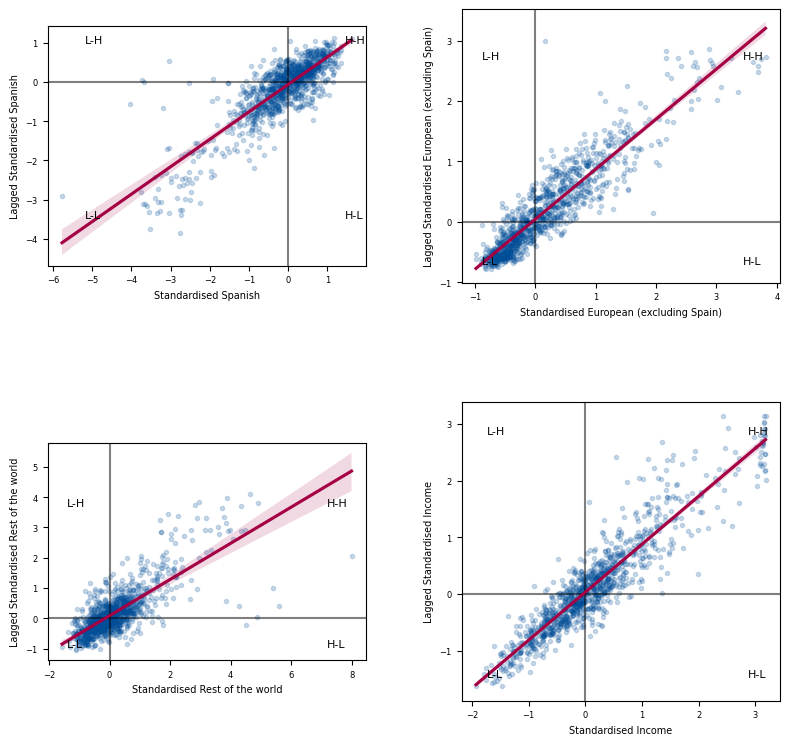

In [6]:
# Build a Queen contiguity spatial weights matrix (neighbours share boundary or vertex)
queen = graph.Graph.build_contiguity(join_bcn, rook=False)
# queen.summary()

# Transform the spatial weights matrix to row-standardised form
queen_row = queen.transform("R")

# Calculate spatial lag for each variable
for col in ["Spanish", "European (excluding Spain)", "Rest of the world", "Income"]:
    join_bcn[col + "_std_lag"] = queen_row.lag(join_bcn[col + "_std"])

# Calculate global Moran's I statistic for each variable
moran_results = {}
for col in ["Spanish", "European (excluding Spain)", "Rest of the world", "Income"]:
    moran = esda.Moran(join_bcn[col + "_std"], queen_row)
    # Store both the I statistic and simulated p-value for assessing significance
    moran_results[col] = {"Moran's I": moran.I, "p-value": moran.p_sim}

# Create a 2x2 grid of Moran scatter plots to visualise spatial autocorrelation
f, ax = plt.subplots(2, 2, figsize=(8, 8))
cols = ["Spanish", "European (excluding Spain)", "Rest of the world", "Income"]
for col, subplot in zip(cols, ax.flatten()):
    # Set equal aspect ratio for Moran plot (standardised variable vs its spatial lag)
    subplot.set_aspect("equal")

    # Add reference lines at zero to divide the plot into quadrants
    subplot.axvline(0, c="black", alpha=0.5)
    subplot.axhline(0, c="black", alpha=0.5)

    # Label each quadrant: H-H (High-High), H-L (High-Low), L-H (Low-High), L-L (Low-Low)
    subplot.text(
        join_bcn[col + "_std"].max() * 0.9,
        join_bcn[col + "_std_lag"].max() * 0.9,
        "H-H",
        fontsize=8,
    )
    subplot.text(
        join_bcn[col + "_std"].max() * 0.9,
        join_bcn[col + "_std_lag"].min() * 0.9,
        "H-L",
        fontsize=8,
    )
    subplot.text(
        join_bcn[col + "_std"].min() * 0.9,
        join_bcn[col + "_std_lag"].max() * 0.9,
        "L-H",
        fontsize=8,
    )
    subplot.text(
        join_bcn[col + "_std"].min() * 0.9,
        join_bcn[col + "_std_lag"].min() * 0.9,
        "L-L",
        fontsize=8,
    )

    # Create regression plot showing the relationship between variable and its spatial lag
    sns.regplot(
        x=col + "_std",
        y=col + "_std_lag",
        data=join_bcn,
        marker=".",
        color="#004d98",
        scatter_kws={"alpha": 0.2},
        line_kws=dict(color="#a50044"),
        ax=subplot,
    )
    subplot.set_xlabel("Standardised " + col, fontsize=7)
    subplot.set_ylabel("Lagged Standardised " + col, fontsize=7)

    subplot.tick_params(axis="both", which="major", labelsize=6)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.2)

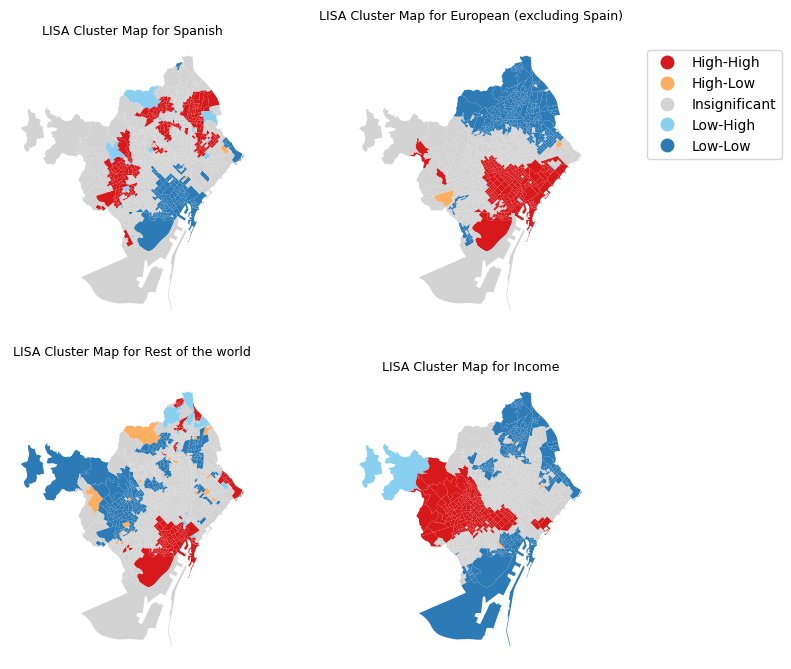

In [7]:
# Calculate and visualise Local Indicators of Spatial Association (LISA) cluster maps
cols = ["Spanish", "European (excluding Spain)", "Rest of the world", "Income"]
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, col in zip(axes.flatten(), cols):
    # Compute local Moran's I for each observation (identifies local clusters and outliers)
    lisa = esda.Moran_Local(join_bcn[col + "_std"], queen_row)

    # Plot LISA results with cluster classification (H-H, L-L, H-L, L-H, or non-significant)
    lisa.plot(join_bcn, ax=ax, legend=True)

    ax.set_title(f"LISA Cluster Map for {col}", fontsize=9)
    ax.legend_.set_bbox_to_anchor((1.8, 1))
    ax.set_axis_off()

    # Remove legend from all subplots except the second one to avoid redundant legends
    if col != "European (excluding Spain)":
        ax.get_legend().remove()

To identify local clusters and outliers, Local Indicators of Spatial Association (LISAs) were computed for each variable. The resulting maps reveal distinct spatial patterns: a cluster of areas with a low proportion of Spanish nationals is found in the city centre, whilst clusters with predominantly Spanish populations are located in the west and north. European nationals form two main clusters: one with high proportions in the western part of the city, and another with low proportions in the north. Areas with a high proportion of non-European nationals are concentrated south of the city centre.

The western part of Barcelona stands out as a clear cluster of high disposable income, which also overlaps with areas where the proportion of non-European nationals is low. The north of the city, around the newest district[<sup>5</sup>](#_blank "Ajuntament Barcelona, nd. Nou Barris. Available at: https://ajuntament.barcelona.cat/noubarris/es/el-distrito-y-sus-barrios") (Nou Barris), by contrast, shows a cluster of low disposable income with a mix of areas having both high and low concentrations of non-European nationals.

Although there is some overlap between areas with high disposable income and those with a high proportion of European nationals, the level of aggregation used in this analysis limits the ability to draw definitive conclusions about the relationship between nationality and income. More detailed data on the characteristics of residents would be necessary to explore this relationship further.

## Part II: Airbnb in Barcelona

This section analyses the spatial distribution of Airbnb listings in Barcelona using data from Inside Airbnb[<sup>6</sup>](#_blank "Available at: http://insideairbnb.com/get-the-data.html"), which includes information on listing locations, types, prices, and availability. The most prevalent type of listings are the ones offering the entire property for rent, with 61% of listings, followed by private rooms at 37%, and shared and hotel rooms with less than 1%. The median price for a 3-bedroom property, the most common size, is €236.

In [8]:
# Defining the URL for Airbnb listings in Barcelona
url = "https://data.insideairbnb.com/spain/catalonia/barcelona/2025-06-12/data/listings.csv.gz"

# Reading the Airbnb data as a pandas DataFrame
listings_df = pd.read_csv(url)

listings_df["price"] = listings_df["price"]. \
    str.replace("$", "", regex=False). \
    str.replace(",", "", regex=False). \
    astype(float)

# Creating a geospatial object and creating the geometry from the coordinates
listings_gpd = gpd.GeoDataFrame(
    listings_df,
    geometry=gpd.points_from_xy(
        x=listings_df["longitude"], y=listings_df["latitude"], crs=4326
    ),
).to_crs(join_bcn.crs)

In [9]:
# # Checking duplicated listings
# listings_gpd.duplicated().sum()

# # Calculating the number of listings by room type
# room_type_counts = listings_gpd["room_type"].value_counts()
# room_type_proportion = 100*room_type_counts / room_type_counts.sum()
# room_type_proportion

# # Calculating the median price of listings by room type
# avg_price_by_room_type = listings_gpd.groupby("room_type")["price"].median()
# avg_price_by_room_type

# # calculating the median price of entire home/apt listings by number of bedrooms
# # Subsetting the data
# entire_home_prices = listings_gpd[
#     listings_gpd["room_type"] == "Entire home/apt"
# ]
# # Calculating median price 
# median_price_by_bedrooms = entire_home_prices.groupby("bedrooms")["price"].median()
# median_price_by_bedrooms

# A histogram with number of bedrooms for entire properties
# sns.histplot(entire_home_prices["bedrooms"],binwidth=1)



As shown in the maps below for the two most common types of properties, listings are heavily concentrated in the geographical centre of the city, around the Old City District, while their number decreases towards the periphery. To test whether the location of listings for the two most common types are due to a random process, Ripley's $G$ and $F$ functions were computed. For both types of Airbnb listings, $G$ indicates significant clustering (p < 0.001), while $F$ suggests weaker clustering, especially for locations where private rooms are offered (p = 0.14).



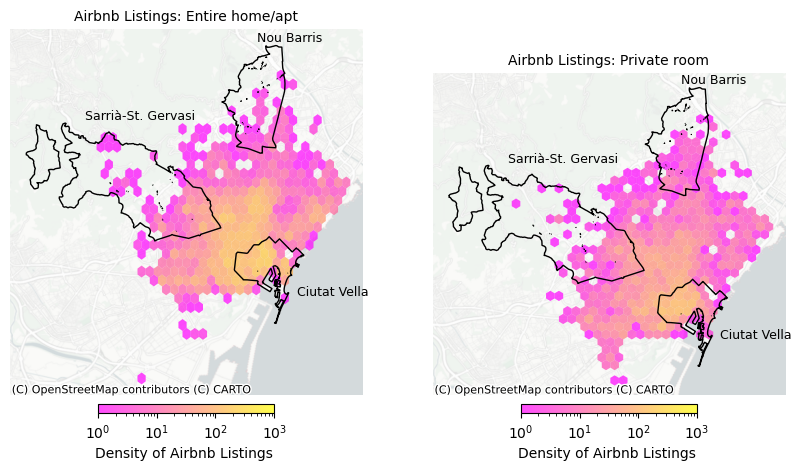

In [10]:
# Extracting the room types for exploring their spatial distribution only for the two most common types
room_types = listings_gpd["room_type"].value_counts().nlargest(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Loop through each room type and create a subplot
for ax, room_type in zip(axes.flatten(), room_types):
    # Filter listings by room type
    subset = listings_gpd[listings_gpd["room_type"] == room_type]

    # # Plot the listings of the specific room type
    # subset.plot(ax=ax, markersize=0.1, color="darkblue", alpha=0.6)

    # Create hexbin
    hb = ax.hexbin(
        subset.geometry.x,
        subset.geometry.y,
        gridsize=30,
        linewidths=0,
        alpha=0.7,
        cmap="spring",
        mincnt=1,
        # Applying a log transformation to better visualise density variations
        norm=colors.LogNorm(vmin=1, vmax=1000),
    )

    # Add boundary of Ciutat Vella for reference
    ciutat_vella_bounds.plot(ax=ax, edgecolor="black", linewidth=1)
    ax.text(
        ciutat_vella_centroid.x + 1000,
        ciutat_vella_centroid.y - 800,
        s="Ciutat Vella",
        fontsize=9,
    )

    # Add boundary of Sarrià-St. Gervasi for reference
    sarria_bounds.plot(ax=ax, edgecolor="black", linewidth=1)
    ax.text(
        sarria_centroid.x - 1000,
        sarria_centroid.y + 2500,
        s="Sarrià-St. Gervasi",
        fontsize=9,
    )

    # Add boundary of Nou Barris
    nou_barris_bounds.plot(ax=ax, edgecolor="black", linewidth=1)
    ax.text(
        nou_barris_centroid.x,
        nou_barris_centroid.y + 2500,
        s="Nou Barris",
        fontsize=9,
    )

    contextily.add_basemap(
        ax=ax,
        crs=listings_gpd.crs,
        source="CartoDB Positron No Labels",
    )

    plt.colorbar(
        hb,
        orientation="horizontal",
        shrink=0.5,
        pad=0.02,
        label="Density of Airbnb Listings ",
    )

    ax.set_title(f"Airbnb Listings: {room_type}", fontsize=10)
    ax.set_axis_off()

# # Loop through each room type to compute g function and f function
# for room_type in room_types:
#     # Filter listings by room type
#     subset = listings_gpd[listings_gpd["room_type"] == room_type]

#     concave_hull = subset.dissolve().concave_hull(ratio=.1)

#     g_test = pointpats.distance_statistics.g_test(
#     subset,
#     support=200,
#     keep_simulations=True,
#     hull=concave_hull.item(),
#     n_simulations=99,
# )
#     f_test = pointpats.distance_statistics.f_test(
#     subset,
#     support=200,
#     keep_simulations=True,
#     hull=concave_hull.item(),
#     n_simulations=99,
# )

#     print(f"Average G-test p-value for {room_type}: {np.mean(g_test.pvalue)}")
#     print(f"Average F-test p-value for {room_type}: {np.mean(f_test.pvalue)}")


# # Average G-test p-value for Entire home/apt: 0.0002
# # Average F-test p-value for Entire home/apt: 0.07700000000000001
# # Average G-test p-value for Private room: 0.0005
# # Average F-test p-value for Private room: 0.1476

To further investigate if the spatial distribution of listings differs by price level, entire home listings were divided into quintiles based on their price. Only properties with three bedrooms were considered to control for size effects. As shown in the figure below, ellipses were computed to summarise the spatial distribution of the listings. The results reveal differences in dispersion across quintiles, with the 1st quintile being the most dispersed and the 5th quintile the least dispersed. Interestingly, all centroids of the ellipses are in the city centre area. This suggests that while all price levels tend to cluster around the city centre, lower-priced listings are more widely spread out across the city.

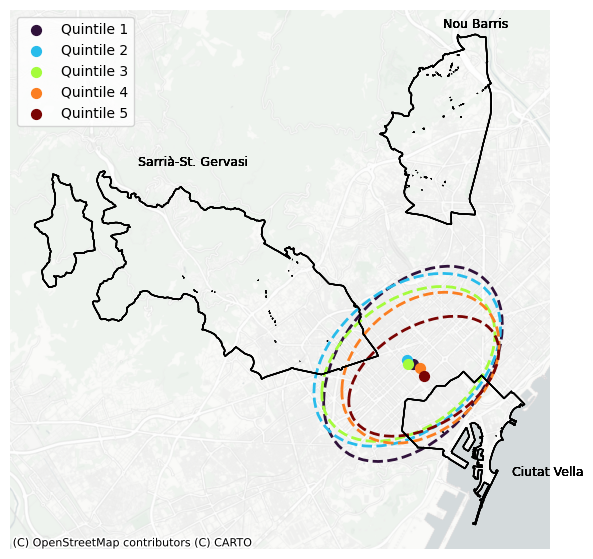

In [11]:
# Subsetting listings for entire properties and 3 rooms
entire_home_3bed = listings_gpd.loc[
    (listings_gpd["room_type"] == "Entire home/apt") & (listings_gpd["bedrooms"] == 3)
].copy()

# Splitting the listings of entire properties with 3 bedrooms into quintiles
entire_home_3bed["price_quintile"] = pd.qcut(
    entire_home_3bed["price"], 5, labels=False
)

# a loop to produce an ellipse for each quintile from 1 to 5 and plot them on the same map
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

for quintile in range(5):
    quintile_subset = entire_home_3bed[entire_home_3bed["price_quintile"] == quintile]

    # Add boundary of Ciutat Vella for reference
    ciutat_vella_bounds.plot(ax=ax, edgecolor="black", linewidth=1)
    ax.text(
        ciutat_vella_centroid.x + 1000,
        ciutat_vella_centroid.y - 800,
        s="Ciutat Vella",
        fontsize=9,
    )

    # Add boundary of Sarrià-St. Gervasi for reference
    sarria_bounds.plot(ax=ax, edgecolor="black", linewidth=1)
    ax.text(
        sarria_centroid.x - 1000,
        sarria_centroid.y + 2500,
        s="Sarrià-St. Gervasi",
        fontsize=9,
    )

    # Add boundary of Nou Barris
    nou_barris_bounds.plot(ax=ax, edgecolor="black", linewidth=1)
    ax.text(
        nou_barris_centroid.x,
        nou_barris_centroid.y + 2500,
        s="Nou Barris",
        fontsize=9,
    )

    contextily.add_basemap(
        ax=ax,
        crs=listings_gpd.crs,
        source="CartoDB Positron No Labels",
    )

    # calculating the standard deviational ellipse
    centroid = pointpats.centrography.mean_center(quintile_subset)
    ellipse = pointpats.centrography.ellipse(quintile_subset)

    # plotting the ellipses and centroids for each quintile
    gpd.GeoSeries([ellipse], crs=entire_home_3bed.crs).plot(
        ax=ax, edgecolor=plt.cm.turbo(quintile / 4), linewidth=2, facecolor="none",linestyle="--"
    )
    gpd.GeoSeries([centroid], crs=entire_home_3bed.crs).plot(
        ax=ax,
        color=plt.cm.turbo(quintile / 4),
        markersize=50,
        label=f"Quintile {quintile + 1}",
    )

    ax.legend(loc="upper left")

    ax.set_axis_off()

## A regionalisation based on Airbnb listings

Using the typical attributes of the Airbnbs in each census area, regions were derived using K-means clustering. The attributes used were: (1) the total number of listings per thousand residents, (2) the median number of bedrooms, (3) the median price, and (4) the number of reviews during the last year as an indicator of its popularity. 

Based on the results of the clustering, five distinct regions were identified across Barcelona. As shown in the map below, census areas in the city centre, particularly in the Old City District, form a cluster characterised with a very high density of listings of small properties (median of 1.3 bedrooms) rented at a high price, which have a low number of reviews in the last year. A second cluster covering a wider region is formed by census areas in the west and south of the city; this cluster show a moderate density of listings (~13 per 1,000 residents), with slightly larger properties at lower prices, and more reviews in the last year than in the previous region. A third big region is located in the north and north-east of the city, characterised by a low density of listings (~2 per 1,000 residents), the smallest properties (median of 1 bedroom) at low prices (median of €600), and the second highest number of reviews.

Two more small regions were identified, both composed of a single census area. The main attribute that differentiates these localised regions is the very high number of reviews in the last year, possibly indicating their popularity among Airbnb users.  

In [12]:
# Joining listings with census sections
listings_census = join_bcn.sjoin(
    listings_gpd, how="inner", predicate="contains"
).reset_index()

# Calculating summary statistics of listings by census section
listings_census_summary = (
    listings_census.groupby("code_sec")
    .agg(
        {
            "id": "count",
            "price": "median",
            "bedrooms": "median",
            "number_of_reviews_ly": "median",
        }
    )
    .reset_index()
).rename(
    columns={
        "id": "listing_count",
        "price": "median_price",
        "bedrooms": "median_bedrooms",
        "number_of_reviews_ly": "median_reviews_ly",
    }
)

# Merging population data with listings summary
pop_listings = agg_total_pop.merge(listings_census_summary, on="code_sec", how="left").fillna(0)

# Calculating listings per 1000 residents
pop_listings["listings_per_1000"] = 1000 * (
    pop_listings["listing_count"] / pop_listings["total_population"]
)

# Merging listings summary with spatial data
bcn_listings = adm_units_bcn[["code_sec", "geometry"]].copy()
bcn_listings = bcn_listings.merge(pop_listings, on="code_sec", how="left")

In [13]:
# Defining the columns related to Airbnb analysis in each census section
airbnb_cols = [
    "listings_per_1000",
    "median_price",
    "median_bedrooms",
    "median_reviews_ly"]

# Standardising the Airbnb related columns
for col in airbnb_cols:
    bcn_listings[col + "_std"] = preprocessing.robust_scale(bcn_listings[[col]])
    
# Creating a list of the standardised column names
airbnb_cols_std = [col + "_std" for col in airbnb_cols]

# # Trying different values of k to find the optimal number of clusters using the elbow method
# inertias = {}

# for k in range(2, 15):
#     kmeans = cluster.KMeans(n_clusters=k, random_state=42)
#     kmeans.fit(bcn_listings[airbnb_cols_std])
#     inertias[k] = kmeans.inertia_

# Plotting the elbow method results
# _ = pd.Series(inertias).plot()
# 5 clusters from the plot 

# Agglomerative clustering with spatial constraints
agg5 = cluster.AgglomerativeClustering(n_clusters=5, connectivity=queen.sparse)
agg5.fit(bcn_listings[airbnb_cols_std])
bcn_listings["agg5"] = agg5.labels_

# An exploration of the characteristics of the 5 clusters as box plots
# fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# for ax, col in zip(axes.flatten(), airbnb_cols):
#     sns.boxplot(
#         x="agg5",
#         y=col,
#         data=bcn_listings,
#         ax=ax,
#     )
#     ax.set_xlabel("Cluster", fontsize=9)
#     ax.set_ylabel(col, fontsize=9)
#     ax.tick_params(axis="both", which="major", labelsize=8) 

# An exploration of the characteristics of the 5 clusters as box plots
# fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# for ax, col in zip(axes.flatten(), airbnb_cols):
#     sns.boxplot(
#         x="agg5",
#         y=col,
#         data=bcn_listings,
#         ax=ax,
#     )
#     ax.set_xlabel("Cluster", fontsize=9)
#     ax.set_ylabel(col, fontsize=9)
#     ax.tick_params(axis="both", which="major", labelsize=8) 

In [14]:
# Extracting the boundaries of each cluster for visualisation
bcn_regions = bcn_listings[["agg5", "geometry"]].dissolve("agg5").reset_index()

# Calculating summary statistics for each region for narrative
region_summary = (
    bcn_listings.groupby("agg5")
    .agg(
        {
            "median_price": "mean",
            "median_reviews_ly": "mean",
            "median_bedrooms": "mean",
            "listings_per_1000": "mean",
        }
    )
    .reset_index()
)

# Merging the summary to the region boundaries for interactive visualisation
bcn_regions = bcn_regions.merge(region_summary, on="agg5", how="left")

# Visualising the clusters on an interactive map
bcn_regions.explore(
    "agg5",
    categorical=True,
    tiles="CartoDB Positron",
    cmap="Set3",
    legend_kwds={"title": "Barcelona Regions by Airbnb Characteristics"},
    tooltip=[
        "agg5",
        "median_price",
        "median_bedrooms",
        "median_reviews_ly",
        "listings_per_1000",
    ],
    control_scale=True,
    zoom=12
)